# Ames Housing — Exploratory Data Analysis

This notebook focuses entirely on
**understanding** the cleaned Ames Housing dataset
— the only goal is to build an accurate, evidence-based
picture of what the data actually looks like, so that every decision made in
later notebooks is grounded in something observed here rather than assumed.

## Table of Contents
1. [Dataset Overview](#overview)
2. [Missing Value Analysis / Target Variable Analysis](#missing)
3. [Univariate Analysis](#univariate)
4. [Correlation Analysis](#correlation)
5. [Bivariate / Multivariate Analysis](#bivariate)
6. [Outlier Investigation](#outliers)
7. [Skewness Analysis](#skewness)
8. [Statistical & Hypothesis Testing](#stats)
9. [EDA Findings & Modeling Implications](#findings)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("AmesHousing_cleaned.csv")
df.shape

(2930, 82)

## 1. Dataset Overview <a name="overview"></a>

In [2]:
df.columns.to_list()

['Order',
 'PID',
 'MS SubClass',
 'MS Zoning',
 'Lot Frontage',
 'Lot Area',
 'Street',
 'Alley',
 'Lot Shape',
 'Land Contour',
 'Utilities',
 'Lot Config',
 'Land Slope',
 'Neighborhood',
 'Condition 1',
 'Condition 2',
 'Bldg Type',
 'House Style',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 'Roof Style',
 'Roof Matl',
 'Exterior 1st',
 'Exterior 2nd',
 'Mas Vnr Type',
 'Mas Vnr Area',
 'Exter Qual',
 'Exter Cond',
 'Foundation',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin SF 1',
 'BsmtFin Type 2',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 'Heating',
 'Heating QC',
 'Central Air',
 'Electrical',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Gr Liv Area',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Full Bath',
 'Half Bath',
 'Bedroom AbvGr',
 'Kitchen AbvGr',
 'Kitchen Qual',
 'TotRms AbvGrd',
 'Functional',
 'Fireplaces',
 'Fireplace Qu',
 'Garage Type',
 'Garage Yr Blt',
 'Garage Finish',
 'Garage Cars',
 'Garage 

In [3]:
df.dtypes.value_counts()

object     43
int64      28
float64    11
Name: count, dtype: int64

In [4]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns.tolist()

print(f"Numerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numerical features: 39
Categorical features: 43


In [5]:
# Numerical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2930.0,6.946519e+01,2.171841e+01,21.0,6.000000e+01,70.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2930.0,1.010969e+02,1.786345e+02,0.0,0.000000e+00,0.0,1.627500e+02,1.600000e+03


- **`describe()` on the numeric columns** immediately surfaces a few things
  worth flagging for later: `Garage Yr Blt`'s minimum and `Total Bsmt SF`'s
  minimum of `0` are legitimate (no garage / no basement), not data errors —
  this matches how those columns were deliberately zero-filled during
  wrangling. `Misc Val`'s 75th percentile is `0` while its max is in the
  thousands, which is an early signal of the heavy right-skew quantified in
  Section 8.

In [6]:
# Categorical summary
df.describe(include=["object", "bool"]).T

,count,unique,top,freq
MS Zoning,2930,7,RL,2273
Street,2930,2,Pave,2918
Alley,2930,3,No Alley,2732
Lot Shape,2930,4,Reg,1859
Land Contour,2930,4,Lvl,2633
Utilities,2930,3,AllPub,2927
Lot Config,2930,5,Inside,2140
Land Slope,2930,3,Gtl,2789
Neighborhood,2930,28,NAmes,443
Condition 1,2930,9,Norm,2522


- **`describe()` on the categorical columns** shows `Neighborhood` has 28
  unique values with `Ames` as the most frequent — a strong signal that
  location will be an important, high-cardinality predictor.
- **Potential modeling challenges already visible:** high-cardinality nominal
  columns, badly skewed numeric columns, mixed scales, and real (not yet
  handled) missingness — none of these are fixed here, only noted for the
  feature-engineering stage.

## 2. Missing Value Analysis <a name="missing"></a>

In [7]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)

missing_summary = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})

if missing_summary.empty:
    print(" Data cleaning complete: No missing values remain.")
else:
    display(missing_summary)


 Data cleaning complete: No missing values remain.


**Observations:**

- Missing values are **primarily structural rather than random**. According to the Data description, `NaN` in features such as `Pool QC`, `Alley`, `Garage *`, `Bsmt *`, and `Misc Feature` indicates the **absence of that feature**, not missing information.
- To preserve this information, these missing values were replaced with descriptive categories (e.g., **"No Garage"**, **"No Basement"**, **"No Pool"**, **"No Alley Access"**) instead of statistical imputation.
- Numerical features with genuine missing values, such as `Lot Frontage`, were imputed using neighborhood medians with the overall median as a fallback when no neighborhood information was available.
- After applying these strategies, the dataset contains **no remaining missing values** and is ready for exploratory data analysis.

### **Target Variable Analysis:** SalePrice <a name="target"></a>

<Axes: xlabel='SalePrice'>

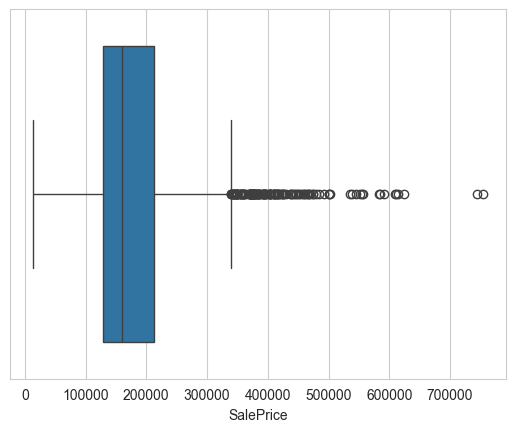

In [8]:
# Inspecting the target variable (SalePrice) Visually

sns.boxplot(x=df["SalePrice"])   

<Axes: xlabel='SalePrice'>

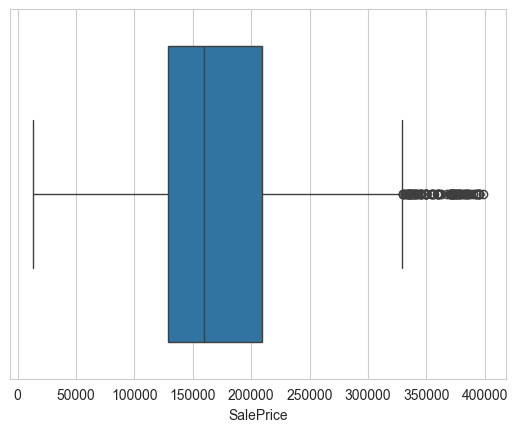

In [9]:
sns.boxplot(x='SalePrice', data=df[df['SalePrice'] < 400000])

#####  **Calculate summary statistics for the 'SalePrice' column**

In [10]:
stats = df["SalePrice"].agg(["mean", "median", "std", "skew", "min", "max"])

print(f"Mean:     ${stats['mean']:,.0f}")
print(f"Median:   ${stats['median']:,.0f}")
print(f"Std Dev:  ${stats['std']:,.0f}")
print(f"Skewness: {stats['skew']:.3f}")
print(f"Min:      ${stats['min']:,.0f}")
print(f"Max:      ${stats['max']:,.0f}")

Mean:     $180,796
Median:   $160,000
Std Dev:  $79,887
Skewness: 1.744
Min:      $12,789
Max:      $755,000


####  **Visualizing the distribution of SalePrice**

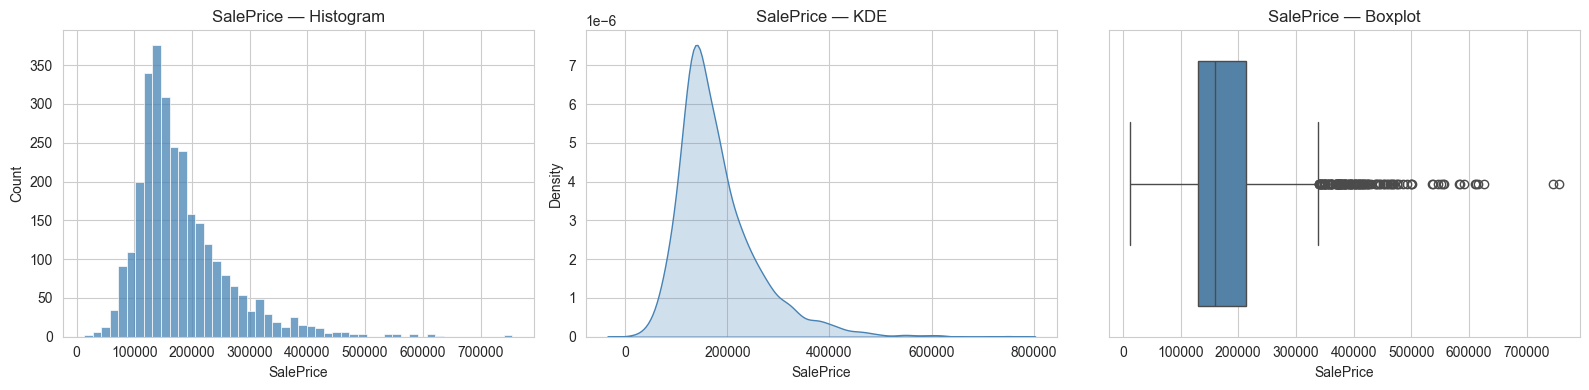

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df["SalePrice"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("SalePrice — Histogram")

sns.kdeplot(df["SalePrice"], fill=True, ax=axes[1], color="steelblue")
axes[1].set_title("SalePrice — KDE")

sns.boxplot(x=df["SalePrice"], ax=axes[2], color="steelblue")
axes[2].set_title("SalePrice — Boxplot")

plt.tight_layout()
plt.show()

**Observations:**

- The **mean (\$180,796) exceeds the median (\$160,000)**, indicating a positively skewed distribution driven by higher-priced homes. 
- **SalePrice is strongly right-skewed (skewness ≈ 1.74)**, with most properties concentrated between **\$100K–\$220K** and a long upper tail extending beyond **\$700K**.
- The **boxplot identifies several high-end outliers**, which are expected in a right-skewed housing market and are not necessarily data errors.
- These findings suggest that the target variable may benefit from a **log transformation** during the preprocessing stage to improve regression performance, although no transformation is applied during EDA.

## 3. Univariate Analysis <a name="univariate"></a>


### 3.1 Numerical Variables
The following numerical variables (`Gr Liv Area`, `Total Bsmt SF`, `Garage Area`, `Lot Area`, `Year Built`, `Overall Qual`) are explored to understand their distributions, variability, and potential influence on house prices. These features represent key structural and property characteristics within the dataset.


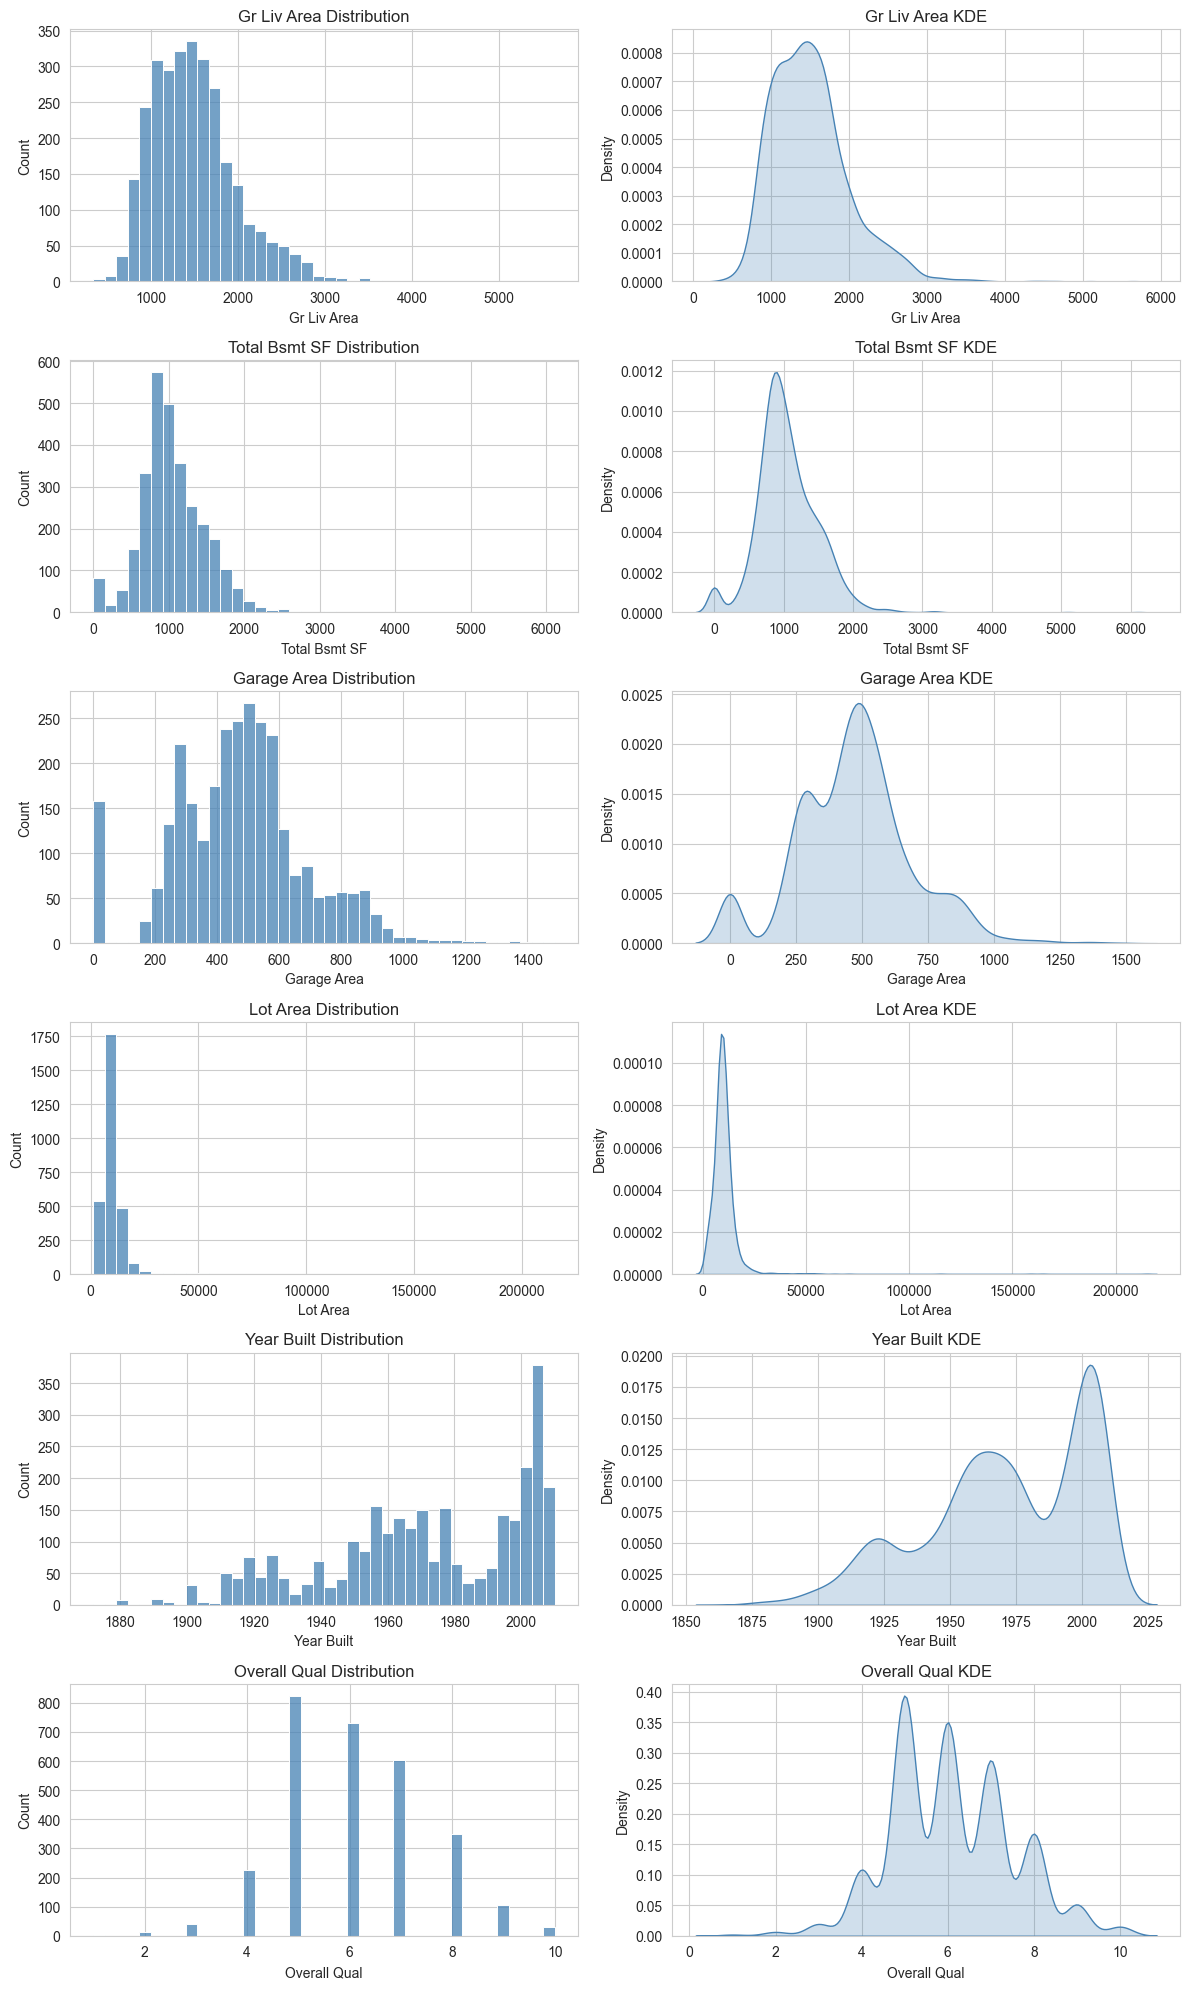

In [12]:
features = [
    "Gr Liv Area",
    "Total Bsmt SF",
    "Garage Area",
    "Lot Area",
    "Year Built",
    "Overall Qual"
]

fig, axes = plt.subplots(len(features), 2, figsize=(12, 20))

for i, feature in enumerate(features):
    sns.histplot(df[feature], bins=40, ax=axes[i, 0], color="steelblue")
    axes[i, 0].set_title(f"{feature} Distribution")

    sns.kdeplot(df[feature], fill=True, ax=axes[i, 1], color="steelblue")
    axes[i, 1].set_title(f"{feature} KDE")

plt.tight_layout()
plt.show()

**Observations:**

- **Gr Liv Area** is moderately right-skewed, with most homes between **800–2,200 sq ft** and a few large homes exceeding **4,000 sq ft**, which are investigated later as potential outliers.
- **Total Bsmt SF** and **Garage Area** both contain a concentration of **0 values**, representing homes without basements or garages, alongside otherwise positively skewed distributions.
- **Lot Area** is the most heavily right-skewed feature, with a small number of exceptionally large lots extending the upper tail.
- **Year Built** is slightly left-skewed, indicating that most homes were built during the second half of the 20th century, with relatively few older properties.
- **Overall Qual** is concentrated around ratings **5–7**, showing that most homes are of average to above-average quality.

**Summary:** Most numerical variables exhibit positive skewness and upper-end outliers, particularly **Lot Area**, **Gr Liv Area**, **Total Bsmt SF**, and **Garage Area**. These patterns will be revisited during the outlier and preprocessing stages.

### 3.2 Categorical Variables
This section explores four important categorical variables — `Neighborhood`, `House Style`, `Bldg Type`, and `Sale Condition` — to understand class distribution and imbalance before they are used in later group comparisons and encoding.


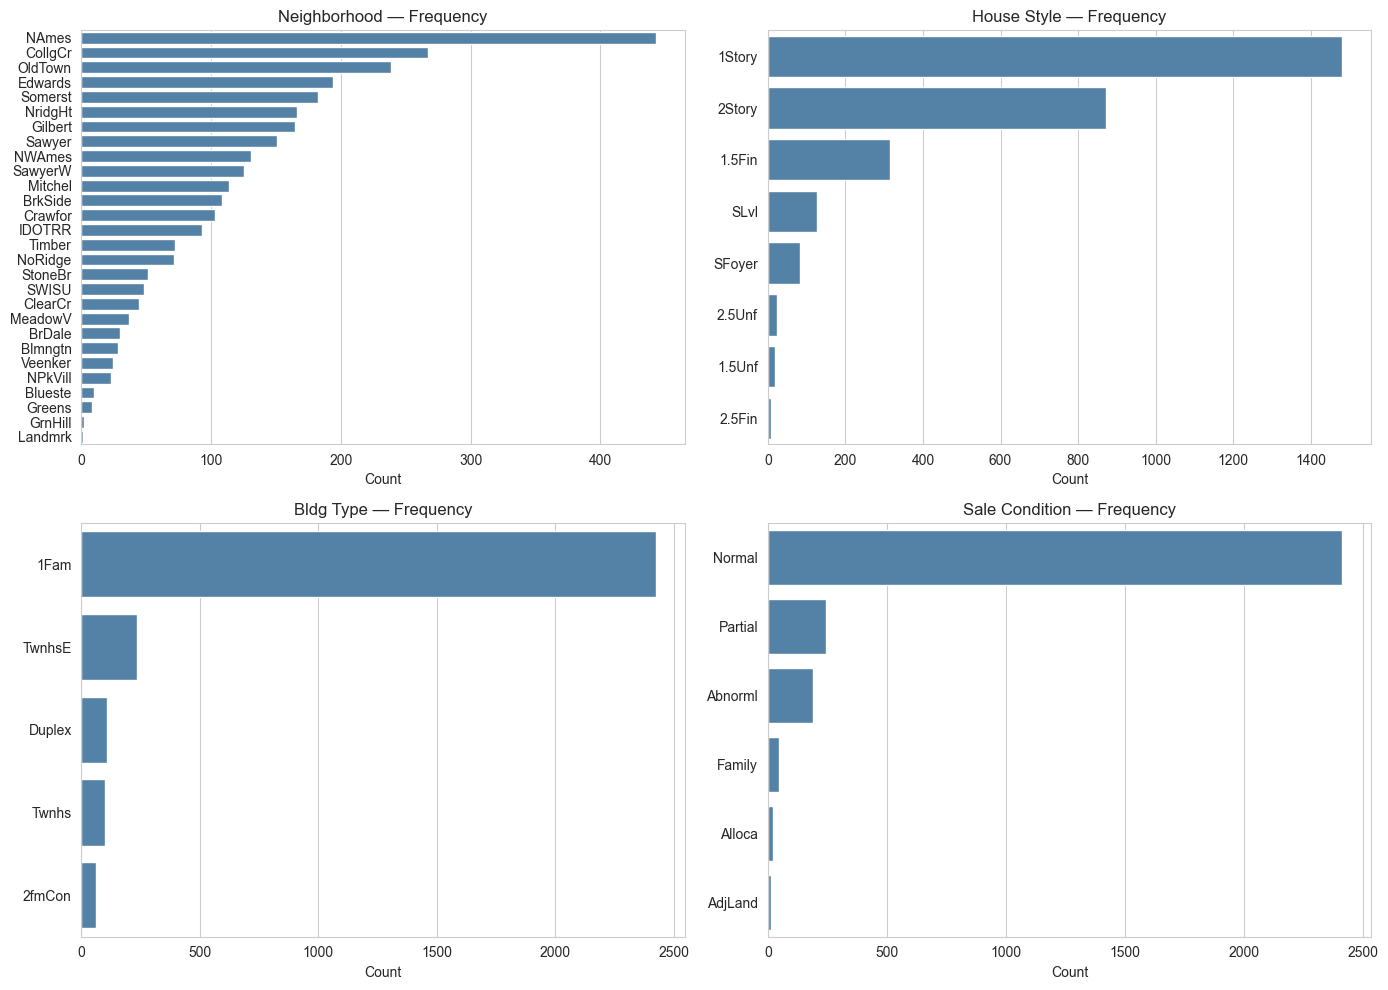

In [13]:
cat_vars = ["Neighborhood", "House Style", "Bldg Type", "Sale Condition"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col} — Frequency")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

**Observations:**

- **Neighborhood** has the highest number of categories and shows an imbalanced distribution, with a few neighborhoods contributing a much larger share of sales than others.
- **House Style** is dominated by one- and two-story homes, while the remaining styles occur relatively infrequently.
- **Bldg Type** is heavily concentrated in single-family homes (`1Fam`), with duplexes and townhouse types representing a much smaller portion of the dataset.
- **Sale Condition** is primarily composed of normal sales, with a smaller number of abnormal and partial sales that may help explain some unusual observations explored later.

**Summary:** The selected categorical variables exhibit varying degrees of class imbalance, which is expected in real-world housing data. These distributions provide valuable context for understanding `SalePrice` and will be considered during feature engineering and model development.

## 4. Correlation Analysis <a name="correlation"></a>


In [14]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

saleprice_corr = corr_matrix["SalePrice"].drop("SalePrice").sort_values(ascending=False).head(7)
saleprice_corr_table = saleprice_corr.to_frame(name="correlation_with_SalePrice")
saleprice_corr_table

,correlation_with_SalePrice
Overall Qual,0.799262
Gr Liv Area,0.706780
Garage Cars,0.647562
Garage Area,0.640138
Total Bsmt SF,0.632529
1st Flr SF,0.621676
Year Built,0.558426


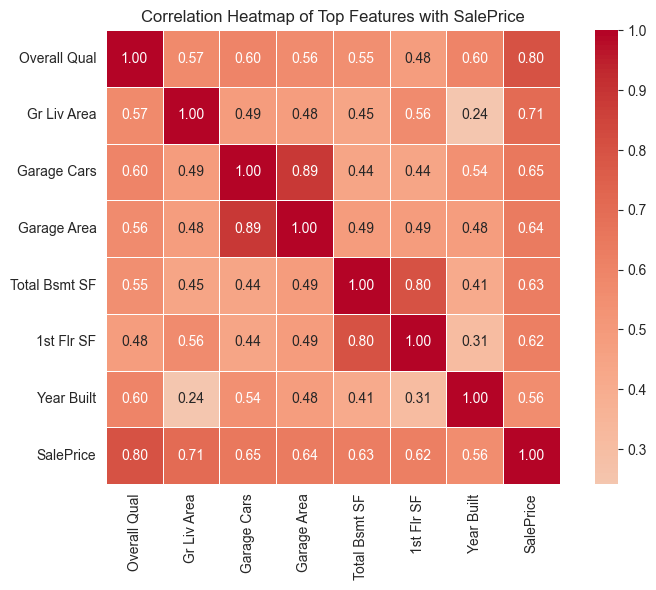

In [15]:
# Select the top features most correlated with SalePrice
top_features = saleprice_corr.index.tolist() + ["SalePrice"]

# Correlation matrix for the selected features
top_corr_matrix = df[top_features].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    top_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Top Features with SalePrice")
plt.tight_layout()
plt.show()

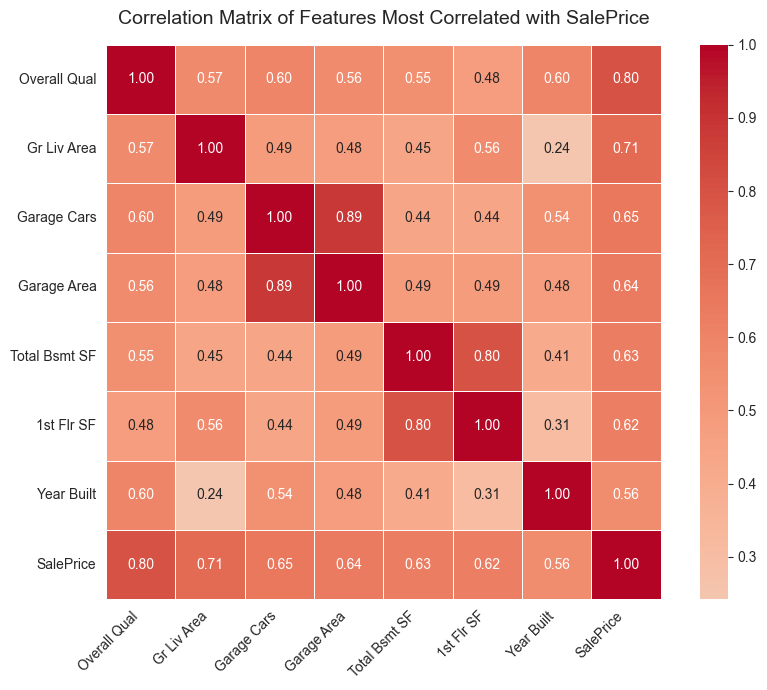

In [16]:
# Correlation matrix for all numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

# Select the top 7 features most correlated with SalePrice
saleprice_corr = (
    corr_matrix["SalePrice"]
    .drop("SalePrice")
    .abs()                         # Use absolute correlation strength
    .sort_values(ascending=False)
)

top_features = saleprice_corr.head(7).index.tolist() + ["SalePrice"]

# Correlation matrix for the selected features
top_corr_matrix = df[top_features].corr()

# Plot heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    top_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={"size": 10}
)

plt.title(
    "Correlation Matrix of Features Most Correlated with SalePrice",
    fontsize=14,
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 4.1 Correlation with Target Variable


In [17]:
corr_with_target = (
    corr_matrix["SalePrice"]
    .sort_values(ascending=False)
    .drop("SalePrice")
)

display(corr_with_target.head(20).to_frame("Correlation"))

,Correlation
Overall Qual,0.799262
Gr Liv Area,0.706780
Garage Cars,0.647562
Garage Area,0.640138
Total Bsmt SF,0.632529
1st Flr SF,0.621676
Year Built,0.558426
Full Bath,0.545604
Garage Yr Blt,0.540262
Year Remod/Add,0.532974


**Observations:**

- **Overall Qual** exhibits the strongest positive correlation with **SalePrice** (**r = 0.80**), indicating that higher construction and finish quality is strongly associated with higher house prices.
- **Gr Liv Area** (**r = 0.71**), **Garage Area** (**r = 0.64**), and **Total Bsmt SF** (**r = 0.63**) also show strong positive relationships with the target, **confirming that larger homes generally command higher sale prices.**
- **Year Built** has a moderate positive correlation (**r = 0.56**), suggesting that newer homes tend to sell for higher prices.
- **Lot Area** has the weakest relationship (**r = 0.27**), indicating that lot size alone is a relatively poor predictor of house value compared with overall quality and living space.

**Summary:** Overall, **Overall Qual** and **Gr Liv Area** emerge as the strongest predictors of `SalePrice`, while the remaining variables exhibit moderate to weak positive relationships. These findings are consistent with earlier visualizations and provide a strong foundation for feature selection and predictive modeling.

### 4.2 Multicollinearity Detection


In [18]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={
             "level_0": "Feature 1",
             "level_1": "Feature 2",
             0: "Correlation"
         })
)

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs["Correlation"].abs() > 0.60
    ]
    .sort_values("Correlation", ascending=False)
    .reset_index(drop=True)
)

high_corr_pairs

,Feature 1,Feature 2,Correlation
0,Garage Cars,Garage Area,0.889866
1,Year Built,Garage Yr Blt,0.853066
2,Gr Liv Area,TotRms AbvGrd,0.807772
3,Total Bsmt SF,1st Flr SF,0.800429
4,Overall Qual,SalePrice,0.799262
5,Gr Liv Area,SalePrice,0.706780
6,Bedroom AbvGr,TotRms AbvGrd,0.672647
7,2nd Flr SF,Gr Liv Area,0.655251
8,Garage Cars,SalePrice,0.647562
9,BsmtFin SF 1,Bsmt Full Bath,0.640212


**Observation:** Several features show strong correlations with one another, indicating potential multicollinearity. The strongest relationships are between Garage Cars and Garage Area (0.890), Year Built and Garage Yr Blt (0.853), Gr Liv Area and TotRms AbvGrd (0.808), and Total Bsmt SF and 1st Flr SF (0.800). These relationships suggest that some variables provide overlapping information, which may be redundant in a linear model.

## 5. Bivariate / Multivariate Analysis <a name="bivariate"></a>
This section examines whether the individually strongest predictors identified above (`Overall Qual`, `Gr Liv Area`, `Garage Cars`, `Garage Area`, `Total Bsmt SF`) behave the way the correlation coefficients suggest once visualized directly against `SalePrice`, and whether they carry overlapping or complementary information.


##### **Relationship Between Gr Liv Area, Overall Qual, and SalePrice**

This section examines whether **Gr Liv Area** and **Overall Qual** influence **SalePrice**, highlighting their relationships with the target variable and identifying any notable trends or outliers.


#### **Overall Qual & SalesPrice**

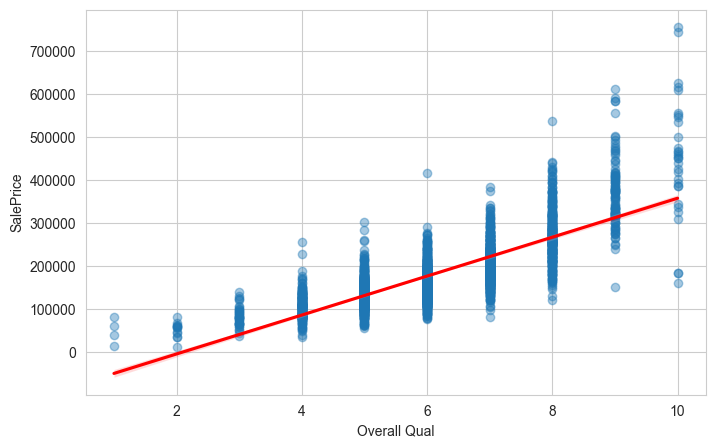

In [19]:
plt.figure(figsize=(8, 5))
sns.regplot(
    x="Overall Qual",
    y="SalePrice",
    data=df,
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)
plt.show()

**Observations:**

The scatter plot reveals a clear positive relationship between **Overall Qual** and **SalePrice**. Higher quality ratings are consistently associated with higher sale prices, indicating that overall construction and finish quality is a strong predictor of house value. Price variability also increases for higher quality homes, reflecting a wider range of prices among premium properties.

#### **Gr Liv Area & SalePrice**

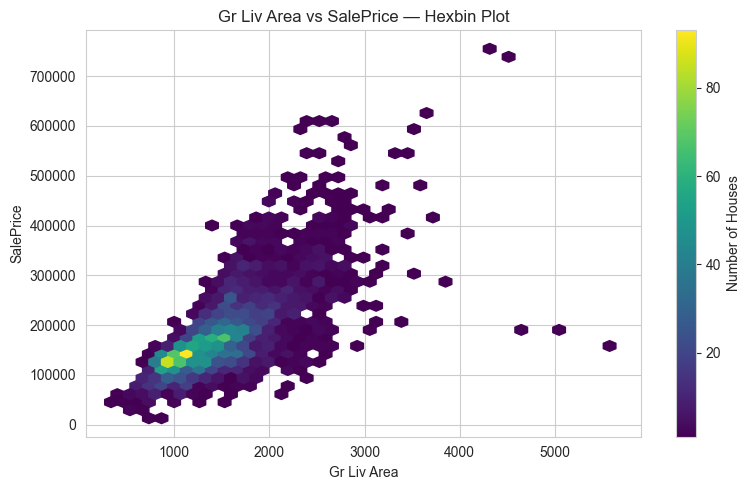

In [20]:
plt.figure(figsize=(8, 5))

plt.hexbin(
    df["Gr Liv Area"],
    df["SalePrice"],
    gridsize=40,
    mincnt=1,
     cmap="viridis"
)

plt.colorbar(label="Number of Houses")
plt.xlabel("Gr Liv Area")
plt.ylabel("SalePrice")
plt.title("Gr Liv Area vs SalePrice — Hexbin Plot")

plt.tight_layout()
plt.show()

**Observations:**

The IQR method identified **four upper-end outliers** in **SalePrice**, all corresponding to properties with a **Gr Liv Area exceeding 4,000 sq ft**. These appear to be legitimate luxury homes rather than data errors, so they are retained. Their influence will be reduced later through a **log transformation** of the target variable instead of removing the observations.

#### **Garage Cars vs SalePrice**

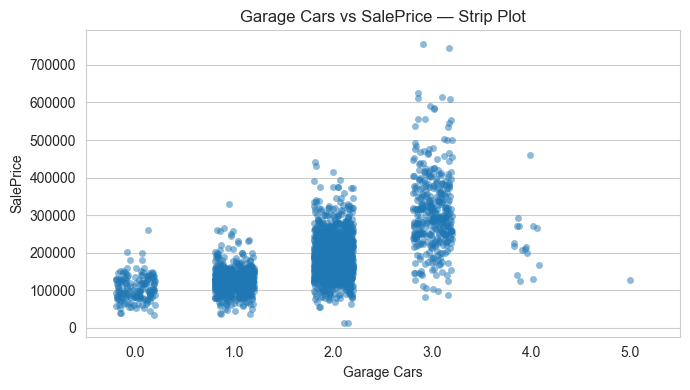

In [21]:
plt.figure(figsize=(7, 4))

sns.stripplot(
    data=df,
    x="Garage Cars",
    y="SalePrice",
    jitter=0.2,
    alpha=0.5
)

plt.title("Garage Cars vs SalePrice — Strip Plot")
plt.tight_layout()
plt.show()

**Observation:** Garage Cars shows a general positive relationship with SalePrice: houses with larger garage capacity tend to have higher sale prices. The difference is especially noticeable between homes with no garage and those with 2–3 car garages. However, there is considerable price variation within each group, suggesting that garage capacity alone does not determine house price and is likely related to other characteristics such as overall size and quality.

#### **Garage Area vs SalePrice**

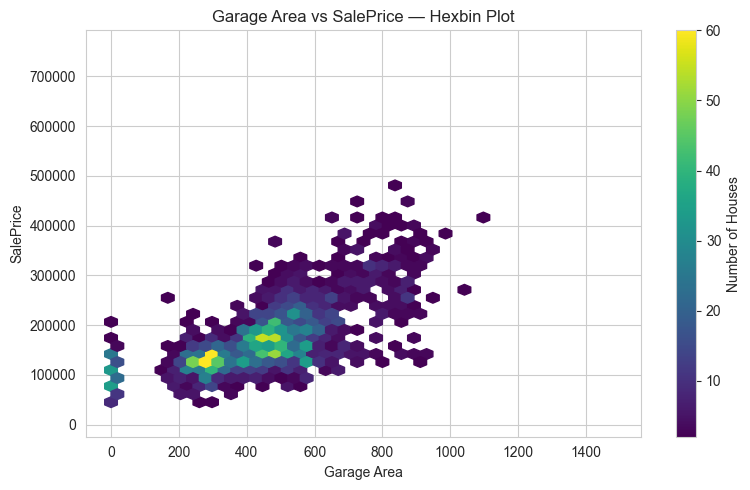

In [22]:
plt.figure(figsize=(8, 5))

plt.hexbin(
    df["Garage Area"],
    df["SalePrice"],
    gridsize=40,
    mincnt=2,
     cmap="viridis"
)

plt.colorbar(label="Number of Houses")
plt.xlabel("Garage Area")
plt.ylabel("SalePrice")
plt.title("Garage Area vs SalePrice — Hexbin Plot")

plt.tight_layout()
plt.show()

**Observation:** Garage Area shows a general positive relationship with SalePrice: houses with larger garage areas tend to have higher sale prices. The relationship is especially noticeable as garage size increases beyond the typical range, where prices generally become higher. However, there is considerable price variation among houses with similar garage areas, suggesting that garage size alone does not determine house price and is likely influenced by other characteristics such as overall size and quality.

#### **Total Bsmt SF vs SalePrice**

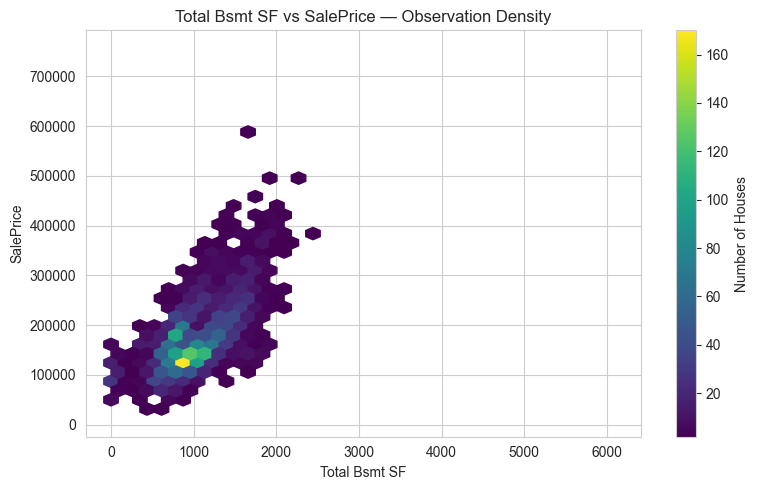

In [23]:
plt.figure(figsize=(8, 5))

plt.hexbin(
    df["Total Bsmt SF"],
    df["SalePrice"],
    gridsize=35,
    mincnt=2,
     cmap="viridis"
   
)

plt.colorbar(label="Number of Houses")

plt.title("Total Bsmt SF vs SalePrice — Observation Density")
plt.xlabel("Total Bsmt SF")
plt.ylabel("SalePrice")

plt.tight_layout()
plt.show()

**Observation:** Total Bsmt SF shows a generally positive relationship with SalePrice: as basement area increases, sale prices tend to increase. However, the relationship is not strong enough to explain price on its own, as there is substantial variation in SalePrice for houses with similar basement sizes.

#### *pairplot*

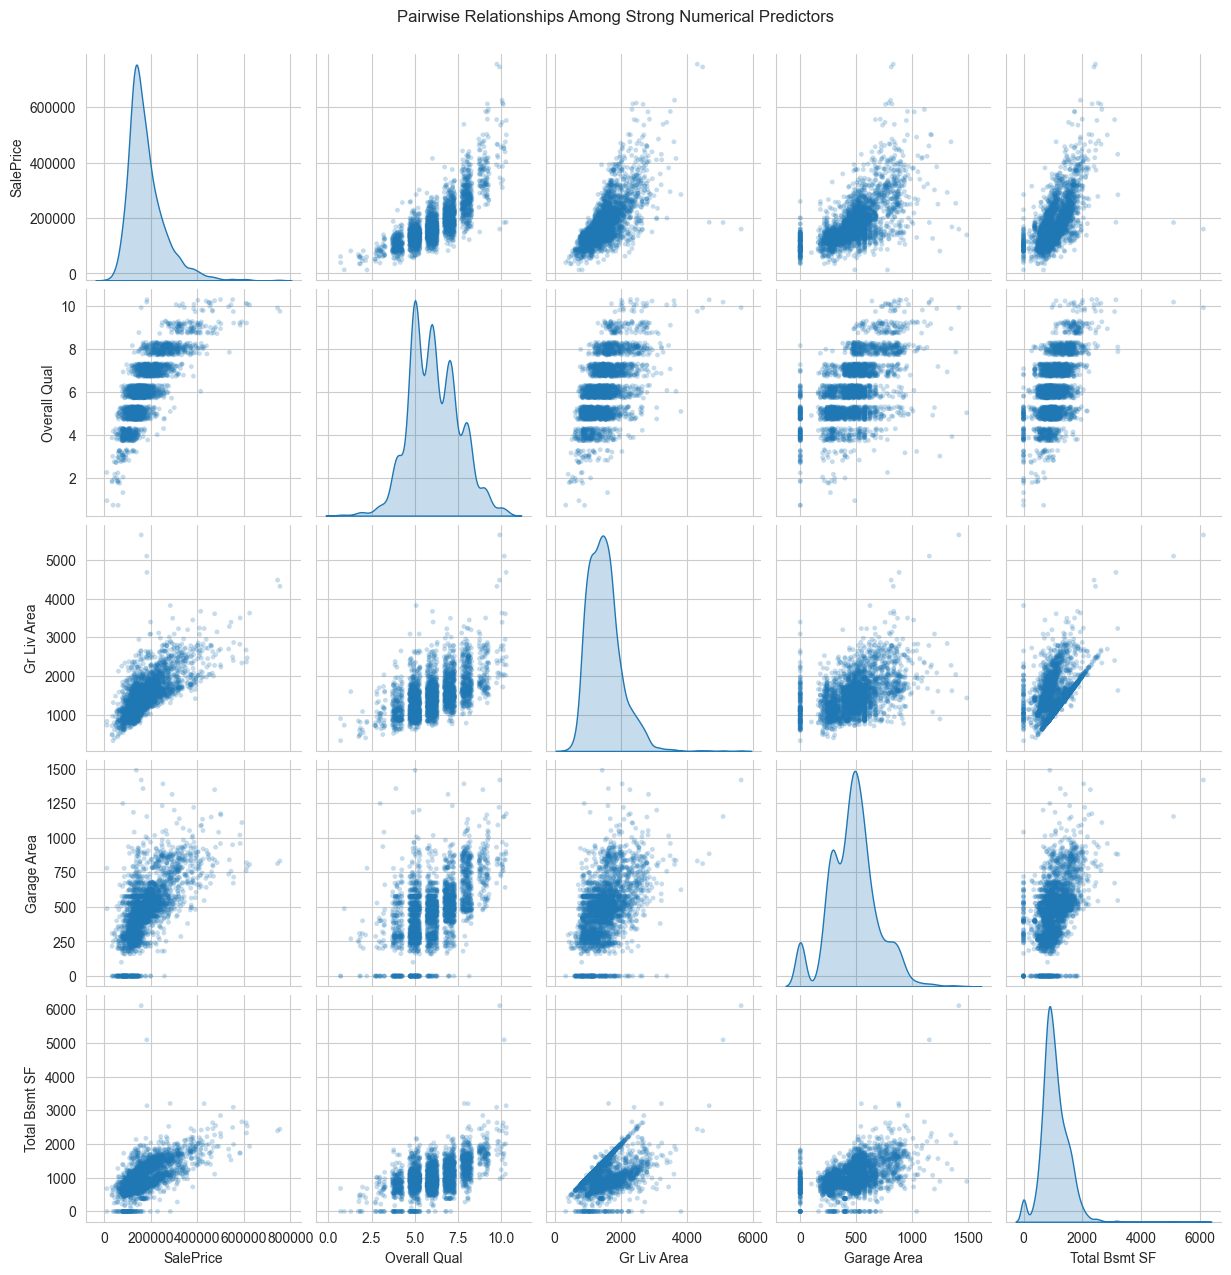

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

pairplot_features = [
    'SalePrice',
    'Overall Qual',
    'Gr Liv Area',
    'Garage Area',
    'Total Bsmt SF'
]

plot_df = df[pairplot_features].copy()

# collapses into vertical/horizontal stripes. Jitter it slightly for plotting
rng = np.random.default_rng(42)
plot_df['Overall Qual'] = plot_df['Overall Qual'] + rng.uniform(-0.3, 0.3, size=len(plot_df))

g = sns.pairplot(
    plot_df,
    diag_kind='kde',
    plot_kws={'alpha': 0.25, 's': 12, 'edgecolor': 'none'},
    diag_kws={'fill': True}
)

g.fig.suptitle(
    'Pairwise Relationships Among Strong Numerical Predictors',
    y=1.02
)

plt.show()

**Pairwise Relationship Observations:**

OverallQual has the strongest relationship with **SalePrice**. Higher quality generally means higher prices, although there is still noticeable variation within each quality level.
**Gr Liv Area** also shows a strong positive relationship with **SalePrice**. Larger homes tend to cost more, but price variation increases for larger homes, with a few extreme observations.
**Garage Area and Total Bsmt SF** both show positive relationships with **SalePrice**, but they are more dispersed. Their concentrations around zero also reveal houses without garages or basements.

**Relationships Between Predictors:**

The predictors are not independent. For example, **larger living areas tend to come with larger basements and garages**, while**higher-quality houses generally have larger areas across these features**. This suggests some overlapping information and possible multicollinearity, which should be measured later rather than assumed from the plots alone.

**Distributions & Outliers:**

Most of the numerical features are right-skewed, especially **SalePrice, Gr Liv Area, Garage Area, and Total Bsmt SF**. Several extreme observations are visible and should be investigated before deciding whether they are genuine houses or problematic data points.


**Observations**: **OverallQual** and **Gr Liv Area** exhibit the clearest positive relationships with **SalePrice**, while **Garage Area** and **Total Bsmt SF** show weaker but still positive associations. At the same time, several predictors are themselves positively related, particularly **Gr Liv Area**and **Total Bsmt SF**, suggesting potential multicollinearity. The distributions also reveal substantial skewness and several extreme observations that needs further investigation.

**Key EDA Takeaway**:

The pairplot shows that house price is influenced by a combination of size, quality, and other property characteristics rather than by any single feature. It also reveals relationships between the predictors themselves, which gives us something important to investigate next: which features provide unique information and which may be carrying similar information.

## 6. Outlier Investigation <a name="outliers"></a>


### 6.1 Computing the IQR


In [25]:
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

Lower bound: 3500.00
Upper bound: 339500.00


#### **Count the outliers**

In [26]:
saleprice_outliers = df[
    (df["SalePrice"] < lower_bound) |
    (df["SalePrice"] > upper_bound)
]

print(f"Number of outliers: {len(saleprice_outliers)}")

Number of outliers: 137


### 6.2 Outliers Before Treatment


####  **Sort the outliers by SalePrice in descending order**

In [27]:
# Sort the outliers by SalePrice in descending order
saleprice_outliers = saleprice_outliers.sort_values("SalePrice", ascending=False)
display(saleprice_outliers)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1767,1768,528351010,60,RL,104.0,21535,Pave,No Alley,IR1,Lvl,...,0,No Pool,No Fence,No Feature,0,1,2007,WD,Normal,755000
1760,1761,528320050,60,RL,160.0,15623,Pave,No Alley,IR1,Lvl,...,555,Ex,MnPrv,No Feature,0,7,2007,WD,Abnorml,745000
2445,2446,528320060,60,RL,118.0,35760,Pave,No Alley,IR1,Lvl,...,0,No Pool,No Fence,No Feature,0,7,2006,WD,Normal,625000
1063,1064,528164060,20,RL,106.0,12720,Pave,No Alley,Reg,HLS,...,144,Ex,No Fence,No Feature,0,2,2008,WD,Normal,615000
44,45,528150070,20,RL,100.0,12919,Pave,No Alley,IR1,Lvl,...,0,No Pool,No Fence,No Feature,0,3,2010,New,Partial,611657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1707,1708,528150110,60,RL,99.0,13069,Pave,No Alley,IR1,Lvl,...,0,No Pool,No Fence,No Feature,0,8,2007,WD,Normal,342000
1106,1107,528365060,60,RL,96.0,10542,Pave,No Alley,Reg,Lvl,...,0,No Pool,No Fence,No Feature,0,8,2008,WD,Normal,341000
497,498,528344040,60,RL,89.0,16545,Pave,No Alley,IR1,Lvl,...,0,No Pool,No Fence,No Feature,0,5,2009,WD,Normal,340000
1805,1806,528482090,60,FV,102.0,11143,Pave,No Alley,IR1,Lvl,...,0,No Pool,No Fence,No Feature,0,12,2007,WD,Normal,340000


In [28]:
# Display the sorted outliers with relevant columns
display(
    saleprice_outliers[
        ["SalePrice", "Overall Qual", "Gr Liv Area",
         "Total Bsmt SF", "Garage Area",
         "Neighborhood", "Year Built"]
    ]
    .sort_values("Gr Liv Area", ascending=False)
    .head(10)
)

,SalePrice,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Area,Neighborhood,Year Built
1760,745000,10,4476,2396.0,813.0,NoRidge,1996
1767,755000,10,4316,2444.0,832.0,NoRidge,1994
2737,415000,6,3672,1836.0,836.0,Edwards,1935
2445,625000,10,3627,1930.0,807.0,NoRidge,1995
2666,475000,10,3608,1107.0,840.0,OldTown,1892
2450,584500,9,3500,1733.0,959.0,NoRidge,1993
1537,381000,8,3447,728.0,1014.0,Crawfor,1935
2330,545224,10,3390,1528.0,758.0,StoneBr,2006
15,538000,8,3279,1650.0,841.0,StoneBr,2003
65,410000,8,3238,2033.0,666.0,NoRidge,1995


**Observation:** The highest SalePrice observations are associated with very high Overall Quality and substantial living space, suggesting that their extreme prices are at least partly supported by their property characteristics.

In [29]:
# Display the lowest-priced observations in the outlier set:
display(
    saleprice_outliers[
        ["SalePrice", "Overall Qual", "Gr Liv Area",
         "Total Bsmt SF", "Garage Area",
         "Neighborhood", "Year Built"]
    ]
    .sort_values("SalePrice", ascending=True)
    .head(10)
)

,SalePrice,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Area,Neighborhood,Year Built
1126,339750,8,2078,1034.0,836.0,Somerst,2007
497,340000,8,2450,1284.0,1069.0,NoRidge,1998
1805,340000,8,2466,1580.0,610.0,Somerst,2004
1106,341000,7,2418,1311.0,983.0,NoRidge,1993
1707,342000,8,2956,1706.0,916.0,NridgHt,2004
2380,342643,9,2596,1249.0,840.0,NridgHt,2006
2392,344133,8,2253,1209.0,575.0,NridgHt,2005
343,345000,8,2704,1952.0,538.0,NAmes,1972
1177,345000,10,2393,970.0,846.0,Somerst,1998
2391,345000,9,2324,1175.0,736.0,NridgHt,2005


**Observation:** Among the lower-priced observations identified as SalePrice outliers, several properties still have relatively high Overall Quality ratings (8–10). This suggests that quality alone does not fully explain the variation in SalePrice, while Gr Liv Area, Total Bsmt SF, and Garage Area also vary considerably without showing a clear pattern within these observations.

#### **Investigating the High-Quality, Relatively Lower-Priced Outliers**

The ten lowest-priced observations in the outlier set ($339,750–$345,000) include several `Overall Qual`
ratings of 8–10, which seems at odds with the strong `Overall Qual` → `SalePrice` relationship established
earlier. Before assuming these are underpriced, we widen the context to `Neighborhood`, `Year Built`,
`Year Remod/Add`, `Overall Cond`, `Garage Cars`, `Full Bath`, `Kitchen Qual`, `Exter Qual`, and
`Sale Condition`, and benchmark each one against same-neighborhood peers of comparable quality.

In [30]:
# Full context for the ten lowest-priced outliers
context_cols = [
    "SalePrice", "Overall Qual", "Overall Cond", "Gr Liv Area", "Total Bsmt SF",
    "Garage Area", "Garage Cars", "Full Bath", "Kitchen Qual", "Exter Qual",
    "Neighborhood", "Year Built", "Year Remod/Add", "Sale Condition"
]

lowest_priced_outliers = saleprice_outliers.sort_values("SalePrice", ascending=True).head(10)
display(lowest_priced_outliers[context_cols])

,SalePrice,Overall Qual,Overall Cond,Gr Liv Area,Total Bsmt SF,Garage Area,Garage Cars,Full Bath,Kitchen Qual,Exter Qual,Neighborhood,Year Built,Year Remod/Add,Sale Condition
1126,339750,8,5,2078,1034.0,836.0,3.0,2,Ex,Gd,Somerst,2007,2008,Partial
497,340000,8,5,2450,1284.0,1069.0,3.0,2,Gd,Gd,NoRidge,1998,1998,Normal
1805,340000,8,5,2466,1580.0,610.0,2.0,3,Gd,Gd,Somerst,2004,2005,Normal
1106,341000,7,5,2418,1311.0,983.0,3.0,2,Gd,Gd,NoRidge,1993,1994,Normal
1707,342000,8,5,2956,1706.0,916.0,3.0,2,Ex,Gd,NridgHt,2004,2004,Normal
2380,342643,9,5,2596,1249.0,840.0,3.0,3,Gd,TA,NridgHt,2006,2006,Partial
2392,344133,8,5,2253,1209.0,575.0,2.0,2,Ex,Gd,NridgHt,2005,2006,Partial
343,345000,8,7,2704,1952.0,538.0,2.0,2,Ex,Gd,NAmes,1972,1995,Normal
1177,345000,10,5,2393,970.0,846.0,2.0,2,Ex,Ex,Somerst,1998,1999,Normal
2391,345000,9,5,2324,1175.0,736.0,3.0,3,Ex,Ex,NridgHt,2005,2006,Partial


#### **Investigating the High-Quality, Relatively Lower-Priced Outliers**

The ten lowest-priced observations in the outlier set ($339,750–$345,000) include several `Overall Qual`
ratings of 8–10, which seems at odds with the strong `Overall Qual` → `SalePrice` relationship established
earlier. Before assuming these are underpriced, we widen the context to `Neighborhood`, `Year Built`,
`Year Remod/Add`, `Overall Cond`, `Garage Cars`, `Full Bath`, `Kitchen Qual`, `Exter Qual`, and
`Sale Condition`, and benchmark each one against same-neighborhood peers of comparable quality.

In [31]:
# Full context for the ten lowest-priced outliers
context_cols = [
    "SalePrice", "Overall Qual", "Overall Cond", "Gr Liv Area", "Total Bsmt SF",
    "Garage Area", "Garage Cars", "Full Bath", "Kitchen Qual", "Exter Qual",
    "Neighborhood", "Year Built", "Year Remod/Add", "Sale Condition"
]

lowest_priced_outliers = saleprice_outliers.sort_values("SalePrice", ascending=True).head(10)
display(lowest_priced_outliers[context_cols])

,SalePrice,Overall Qual,Overall Cond,Gr Liv Area,Total Bsmt SF,Garage Area,Garage Cars,Full Bath,Kitchen Qual,Exter Qual,Neighborhood,Year Built,Year Remod/Add,Sale Condition
1126,339750,8,5,2078,1034.0,836.0,3.0,2,Ex,Gd,Somerst,2007,2008,Partial
497,340000,8,5,2450,1284.0,1069.0,3.0,2,Gd,Gd,NoRidge,1998,1998,Normal
1805,340000,8,5,2466,1580.0,610.0,2.0,3,Gd,Gd,Somerst,2004,2005,Normal
1106,341000,7,5,2418,1311.0,983.0,3.0,2,Gd,Gd,NoRidge,1993,1994,Normal
1707,342000,8,5,2956,1706.0,916.0,3.0,2,Ex,Gd,NridgHt,2004,2004,Normal
2380,342643,9,5,2596,1249.0,840.0,3.0,3,Gd,TA,NridgHt,2006,2006,Partial
2392,344133,8,5,2253,1209.0,575.0,2.0,2,Ex,Gd,NridgHt,2005,2006,Partial
343,345000,8,7,2704,1952.0,538.0,2.0,2,Ex,Gd,NAmes,1972,1995,Normal
1177,345000,10,5,2393,970.0,846.0,2.0,2,Ex,Ex,Somerst,1998,1999,Normal
2391,345000,9,5,2324,1175.0,736.0,3.0,3,Ex,Ex,NridgHt,2005,2006,Partial


In [32]:
# Benchmark each observation against same-neighborhood peers of similar quality (Overall Qual +/- 1)
# peer_median is the fix: the typical price paid for a house that's genuinely comparable — same neighborhood,
# same quality tier. It's the fair benchmark.

benchmark_rows = []

for idx, row in lowest_priced_outliers.iterrows():
    peers = df[
        (df["Neighborhood"] == row["Neighborhood"]) &
        (df["Overall Qual"].between(row["Overall Qual"] - 1, row["Overall Qual"] + 1)) # -1= 9, +1= 11, .between(9, 11) keeps rows where quality is 9, 10, or 11.
    ]
    peer_median = peers["SalePrice"].median()
    benchmark_rows.append({
        "Index": idx,
        "Neighborhood": row["Neighborhood"],
        "Overall Qual": row["Overall Qual"],
        "SalePrice": row["SalePrice"],
        "Peer Median (Qual +/-1, same Neighborhood)": peer_median,
        "N Peers": len(peers),
        "% of Peer Median": round(row["SalePrice"] / peer_median * 100, 1)
    })

benchmark_df = pd.DataFrame(benchmark_rows).set_index("Index")
display(benchmark_df)

,Neighborhood,Overall Qual,SalePrice,"Peer Median (Qual +/-1, same Neighborhood)",N Peers,% of Peer Median
Index,,,,,,
1126,Somerst,8,339750,231174.0,154,147.0
497,NoRidge,8,340000,300750.0,66,113.1
1805,Somerst,8,340000,231174.0,154,147.1
1106,NoRidge,7,341000,290000.0,61,117.6
1707,NridgHt,8,342000,315000.0,145,108.6
2380,NridgHt,9,342643,335000.0,134,102.3
2392,NridgHt,8,344133,315000.0,145,109.2
343,NAmes,8,345000,186000.0,27,185.5
1177,Somerst,10,345000,315000.0,14,109.5


**Observations:**

- Every one of the ten observations sells **at or above the median price of comparable homes** in the
  same neighborhood at a similar quality level — ranging from **102% to 185% of the peer median**, with
  most clustered around 105–115%. None of them are underpriced relative to their local context.
- They only appear "low" because the outlier set as a whole spans an extreme range
  (**$339,500–$755,000**), dominated at the top by much larger homes (`Gr Liv Area` 3,200–4,500 sq ft)
  concentrated in **NoRidge** and **NridgHt**. Within the outlier subset, `Gr Liv Area` correlates with
  `SalePrice` at **r ≈ 0.53**, so smaller living area — not weaker quality or a pricing error — largely
  explains their position near the bottom of that range.
- `Overall Cond`, `Kitchen Qual`, and `Exter Qual` are consistently average-to-excellent across the group
  (`Overall Cond` mostly 5; `Kitchen Qual`/`Exter Qual` mostly "Gd"/"Ex"), so there is no sign of hidden
  condition problems dragging these prices down.
- `Sale Condition` is mostly **Normal**, with a few **Partial** sales (new-construction homes sold before
  completion). Partial sales in this dataset trend toward *higher*, not lower, prices, so this does not
  explain the relatively lower position either.
- The one partial exception, index **343** (`NAmes`, built 1972, remodeled 1995, `Overall Cond` = 7),
  sits in a non-premium neighborhood yet still prices at **185% of its local peer median** — driven by an
  above-average `Overall Cond` and a `Gr Liv Area` (2,704 sq ft) that is large for that neighborhood, not
  by any pricing anomaly.

**Conclusion:** These observations are not true anomalies. Once neighborhood and quality context are
accounted for, all ten sit at or comfortably above the norm for comparable homes — they simply occupy the
lower end of an outlier set whose upper end is driven by much larger luxury properties. No removal or
special handling is warranted here; they will be retained as legitimate, well-explained observations.

### 6.3 Outlier Investigation — Next Steps

Having examined the top and bottom `SalePrice` outliers individually, we now step back and check the remaining questions systematically before deciding whether any treatment is warranted: data-quality errors, plausibility of extreme values, regression influence/leverage, and feature-level outliers in `Gr Liv Area`, `Total Bsmt SF`, `Lot Area`, and `Garage Area`.


#### 6.3.1 Data-Quality / Logical-Consistency Checks


In [33]:
# Logical consistency conditions
checks = {
    "Remodeled before built": df["Year Remod/Add"] < df["Year Built"],
    "Garage built after sale": df["Garage Yr Blt"] > df["Yr Sold"],
    "Garage built before house": df["Garage Yr Blt"] < df["Year Built"],
    "Remodeled after sale": df["Year Remod/Add"] > df["Yr Sold"],
    "No bathrooms": (df["Full Bath"] + df["Half Bath"]) == 0 #Adding them gives you the total bathroom count above ground for that house,not counting anything in the basement.
} 

# Summary
for name, condition in checks.items():
    print(f"{name}: {condition.sum()} observations")

display(
    df[df["Garage Yr Blt"] > df["Yr Sold"]]
    [["PID", "Neighborhood", "Year Built", "Garage Yr Blt", "Yr Sold", "Sale Condition"]]
)

Remodeled before built: 1 observations
Garage built after sale: 2 observations
Garage built before house: 18 observations
Remodeled after sale: 3 observations
No bathrooms: 3 observations


,PID,Neighborhood,Year Built,Garage Yr Blt,Yr Sold,Sale Condition
2180,908154195,Edwards,2008,2008.0,2007,Partial
2260,916384070,Timber,2006,2207.0,2007,Partial


**Observations:**

- One record (`Garage Yr Blt` = **2207**, Timber neighborhood) is a clear data-entry typo — almost
  certainly meant to be 2007, given `Year Built` = 2006 and `Yr Sold` = 2007. This does not affect
  `SalePrice` directly but should be **corrected** (not removed) before any garage-age feature is
  engineered.
- A handful of `Year Remod/Add` / `Garage Yr Blt` values that fall one year after `Yr Sold` all belong to
  **Partial** sale conditions — new-construction homes sold under contract before the build/remodel was
  fully finished and dated. This is a known characteristic of this dataset's `Partial` sales, not an
  error.
- The three houses with zero above-grade bathrooms all have a basement full bath instead — plausible for
  split-level/basement-oriented homes, not a data error.
- No duplicate `PID`s, no non-positive `SalePrice` or `Gr Liv Area`, and `1st Flr SF + 2nd Flr SF` matches
  `Gr Liv Area` for every row. **No genuine data-quality errors affect `SalePrice` itself.**

In [34]:
# 1. Identify the inconsistent record
remod_issue = df["Year Remod/Add"] < df["Year Built"]

display(
    df.loc[
        remod_issue,
        ["PID", "Neighborhood", "Year Built", "Year Remod/Add", "Yr Sold"]
    ]
)

,PID,Neighborhood,Year Built,Year Remod/Add,Yr Sold
850,907194160,CollgCr,2002,2001,2009


In [35]:
# Fix temporal inconsistency:
# Year Remod/Add cannot logically be earlier than Year Built.
df.loc[df["PID"] == 907194160, "Year Remod/Add"] = 2002 

# Verify
print(
    "Remodeled before built:",
    (df["Year Remod/Add"] < df["Year Built"]).sum()
)

Remodeled before built: 0


**One observation** had Year Remod/Add (2001) earlier than Year Built (2002), which is temporally inconsistent. Since the difference is only one year and no plausible remodeling can precede construction, the value was corrected to 2002 to maintain logical consistency.

In [36]:
# Fix the obvious typo in Garage Yr Blt
df.loc[df["Garage Yr Blt"] == 2207, "Garage Yr Blt"] = 2007 

# Verify the correction
display(
    df[df["Garage Yr Blt"] > df["Yr Sold"]]
    [["PID", "Neighborhood", "Year Built", "Garage Yr Blt", "Yr Sold", "Sale Condition"]]
    .style.format({"Garage Yr Blt": "{:.0f}"})
)

,PID,Neighborhood,Year Built,Garage Yr Blt,Yr Sold,Sale Condition
2180,908154195,Edwards,2008,2008,2007,Partial


#### 6.3.2 Plausibility and Regression Influence


In [37]:
# Check the classic large-GrLivArea houses regardless of SalePrice-outlier status
display(
    df[df["Gr Liv Area"] > 4000]
    [["PID", "Neighborhood", "Overall Qual", "Gr Liv Area", "Total Bsmt SF",
      "Garage Area", "SalePrice", "Sale Condition"]]
    .sort_values("Gr Liv Area", ascending=False)
)

,PID,Neighborhood,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Area,SalePrice,Sale Condition
1498,908154235,Edwards,10,5642,6110.0,1418.0,160000,Partial
2180,908154195,Edwards,10,5095,5095.0,1154.0,183850,Partial
2181,908154205,Edwards,10,4676,3138.0,884.0,184750,Partial
1760,528320050,NoRidge,10,4476,2396.0,813.0,745000,Abnorml
1767,528351010,NoRidge,10,4316,2444.0,832.0,755000,Normal


**Observation:** Five houses exceed 4,000 sq ft of living area. Two (NoRidge, \$745K–\$755K) are the
legitimate luxury outliers already confirmed above — huge, top-quality homes priced accordingly. The
other **three, all in Edwards under a `Partial` sale condition, are a different story**: `Overall Qual` =
10 and up to 5,642 sq ft of living area, yet selling for only **\$160,000–\$185,000** — far below what
their size and quality would predict, and well below the *entire dataset's* typical price range for
homes even a third their size. These did not surface in the earlier `SalePrice`-IQR check because their
prices aren't unusual on their own — they're only implausible once matched against `Gr Liv Area` and
`Overall Qual`, which is exactly the kind of case a marginal-distribution check misses.

In [38]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [39]:
# Quantify influence: fit a baseline OLS and compute Cook's distance / leverage
# OLS (Ordinary Least Squares): fits a linear relationship between predictors and SalePrice.
# We use it to understand relationships and assess which observations may have an unusually large influence on the fitted model.
# Leverage: identifies observations with unusual predictor (X) values that have the potential to strongly affect the regression line.
# Cook’s Distance: identifies observations that actually have a large influence on the fitted regression model, combining their unusualness and their effect on the model.
import statsmodels.api as sm

X = sm.add_constant(df[["Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Garage Area"]])
y = df["SalePrice"]

ols_model = sm.OLS(y, X).fit()
influence = ols_model.get_influence()

diagnostics = df[["PID", "Neighborhood", "Overall Qual", "Gr Liv Area", "SalePrice", "Sale Condition"]].copy()
diagnostics["Cooks_D"] = influence.cooks_distance[0]
diagnostics["Std_Resid"] = influence.resid_studentized_internal

cooks_threshold = 4 / len(df)
print(f"Cook's D threshold (4/n): {cooks_threshold:.5f}")
print(f"Observations exceeding threshold: {(diagnostics['Cooks_D'] > cooks_threshold).sum()}")

display(diagnostics.sort_values("Cooks_D", ascending=False).head(8))

Cook's D threshold (4/n): 0.00137
Observations exceeding threshold: 185


,PID,Neighborhood,Overall Qual,Gr Liv Area,SalePrice,Sale Condition,Cooks_D,Std_Resid
1498,908154235,Edwards,10,5642,160000,Partial,2.927667,-14.720269
2180,908154195,Edwards,10,5095,183850,Partial,1.205047,-11.868000
2181,908154205,Edwards,10,4676,184750,Partial,0.293308,-9.015212
1767,528351010,NoRidge,10,4316,755000,Normal,0.133970,7.427961
1760,528320050,NoRidge,10,4476,745000,Abnorml,0.133944,7.035994
2445,528320060,NoRidge,10,3627,625000,Normal,0.037659,5.292203
1637,527216080,StoneBr,9,2338,591587,Partial,0.035071,5.559276
1063,528164060,NridgHt,10,2470,615000,Normal,0.034350,5.970287


**Observations:**

- The three Edwards `Partial`-sale houses dominate the influence ranking by a wide margin — Cook's D of
  **2.93, 1.21, and 0.29**, hundreds to thousands of times the 4/n threshold (0.0014), with standardized
  residuals around **−9 to −15**. These are exactly the observations a linear model would distort itself
  around trying to fit. **They are a genuine problem for modeling, not just a curiosity.** 
   **Remove** the 3 Edwards homes; **retain** the NoRidge home
- The two legitimate NoRidge luxury homes are also influential (Cook's D ≈ 0.13, residuals ≈ +7), but for
  the right reason — they're real, well-explained high-end sales. Their leverage is a skewness problem to
  manage (via the log-transform already planned for `SalePrice`), not an error to remove.
- One additional case worth flagging: a Veenker property (`Overall Qual` = 9, `Gr Liv Area` = 2,944)
  sold for only \$150,000 under a **`Family`** sale condition — a non-arm's-length transaction, which
  plausibly explains the below-market price and its resulting influence.

#### 6.3.3 Feature-Level Outliers in Size Variables


In [40]:
# IQR-based outlier counts for key size/area predictors
for col in ["Gr Liv Area", "Total Bsmt SF", "Lot Area", "Garage Area"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lb, ub = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lb) | (df[col] > ub)).sum()
    print(f"{col:15s} bounds=[{lb:>8.0f}, {ub:>8.0f}]  outliers={n_out:>4d} ({n_out/len(df)*100:.1f}%)  max={df[col].max():,.0f}")

Gr Liv Area     bounds=[     201,     2668]  outliers=  75 (2.6%)  max=5,642
Total Bsmt SF   bounds=[      30,     2064]  outliers= 124 (4.2%)  max=6,110
Lot Area        bounds=[    1268,    17728]  outliers= 127 (4.3%)  max=215,245
Garage Area     bounds=[     -64,      960]  outliers=  42 (1.4%)  max=1,488


**Observations:**

- Feature-level outlier rates are modest: **2.6% for `Gr Liv Area`, 4.2% for `Total Bsmt SF`, 4.3% for
  `Lot Area`, and 1.4% for `Garage Area`** — consistent with the right-skew already noted in the
  univariate section, not with widespread data problems.
- The single largest `Lot Area` (215,245 sq ft, Timber) belongs to a `Normal`-condition sale with an
  ordinary-sized, average-quality home — an unusually large, irregularly shaped lot (`IR3`), which is
  plausible for that neighborhood rather than an error. Extreme `Lot Area` values like this will still
  warrant a log-transform or capping at the feature-engineering stage so they don't dominate
  distance-based or linear models, but that is a transformation decision, not a removal one.

## 7. Skewness Analysis <a name="skewness"></a>

`SalePrice`'s right skew was already flagged in the target-variable analysis (Section 2) and in the univariate analysis (Section 3.1), and a log-transform of the target was already anticipated as part of the outlier-handling decision (Section 6.4). This section is not a re-discovery exercise -- it asks a narrower, decision-relevant question: **which predictors are skewed in a way that a transformation would actually help, and which are skewed for reasons a transformation cannot fix?**

In [49]:
numeric_cols_for_skew = [c for c in df.select_dtypes(include=[np.number]).columns if c not in ["Order", "PID"]]

skew_summary = pd.DataFrame({
    "skewness": df[numeric_cols_for_skew].skew(),
    "zero_fraction": (df[numeric_cols_for_skew] == 0).mean(),
    "corr_with_SalePrice": df[numeric_cols_for_skew].corrwith(df["SalePrice"]),
}).sort_values("skewness", ascending=False)

skew_summary.head(20).round(3)

,skewness,zero_fraction,corr_with_SalePrice
Misc Val,22.000,0.965,-0.016
Pool Area,16.939,0.996,0.068
Lot Area,12.821,0.000,0.267
Low Qual Fin SF,12.118,0.986,-0.038
3Ssn Porch,11.404,0.987,0.032
Kitchen AbvGr,4.314,0.001,-0.120
BsmtFin SF 2,4.141,0.880,0.006
Enclosed Porch,4.014,0.843,-0.129
Screen Porch,3.957,0.913,0.112
Bsmt Half Bath,3.942,0.940,-0.036


**Reading this table:** raw skewness alone is a poor guide to action. A `log1p` transform reshapes a *continuous* right tail -- it does very little for a variable whose skew comes from most values sitting at exactly zero. Splitting the skewed numeric features by `zero_fraction` separates these two very different situations.

**Group A -- high zero-mass ("mostly absent") features:** `Misc Val`, `Pool Area`, `3Ssn Porch`, `Low Qual Fin SF`, `Screen Porch`, `Enclosed Porch`, `BsmtFin SF 2`, and `Bsmt Half Bath` all have 84 to 99.6% of rows at zero, skewness in the 4-22 range, and correlation with `SalePrice` under 0.13 in magnitude. Their apparent "skew" is really a rare-feature indicator problem, not a distributional one -- `log1p` would barely change their shape and would not add predictive signal that a binary "has this feature" flag doesn't already capture.
**Decision: do not transform. Skip.** If any of these are used at all downstream, a binary presence flag (already planned in `workflow.ipynb`'s Feature Creation step) is the appropriate treatment, not a log transform.

**Group B -- genuinely continuous, moderately skewed, and correlated with the target:** `Gr Liv Area` (skew 1.27, r = 0.71), `Total Bsmt SF` (skew 1.15, r = 0.63), `1st Flr SF` (skew 1.47, r = 0.62), and `BsmtFin SF 1` (skew 1.42, r = 0.43) have low zero-mass and meaningful relationships with `SalePrice`. These are worth transforming **at the modeling stage, and only for linear/distance-based models** -- tree ensembles are invariant to monotonic transforms of a single feature, so the benefit is model-dependent, not universal.

**Group C -- extreme, isolated skew:** `Lot Area` (skew 12.8, zero-mass 0%, r = 0.27) is the one feature with both a genuinely continuous distribution *and* an extreme tail driven by a handful of very large lots -- this is the same pattern already surfaced in the feature-level outlier check (Section 6.3.3). It is weakly correlated with `SalePrice`, so the transform matters more for stabilizing variance than for adding predictive strength.

## 8. Statistical & Hypothesis Testing <a name="stats"></a>

This is one combined stage rather than two separate ones, and that grouping holds up: every test below is framed as a hypothesis (H0 / H1), so splitting "statistical analysis" from "hypothesis testing" into separate top-level sections would just duplicate the same tests under two headings. Each test is chosen because its outcome bears on a specific downstream decision -- test selection, feature retention, or how `SalePrice` is modeled -- not because a generic checklist includes it.

### 8.1 Normality Check -- Does `SalePrice` Need a Log-Transform for Modeling?

**Research question:** Is `SalePrice` normally distributed, and does a log-transform meaningfully move it toward normality?

- **H0:** `SalePrice` (and separately, `log1p(SalePrice)`) is drawn from a normal distribution.
- **H1:** It is not.
- **Test:** Shapiro-Wilk, alpha = 0.05.

In [44]:
from scipy import stats

sw_raw = stats.shapiro(df["SalePrice"].sample(2000, random_state=42))
sw_log = stats.shapiro(np.log1p(df["SalePrice"]).sample(2000, random_state=42))

print(f"Raw SalePrice      -- W = {sw_raw.statistic:.4f}, p = {sw_raw.pvalue:.2e}, skew = {df['SalePrice'].skew():.3f}")
print(f"log1p(SalePrice)   -- W = {sw_log.statistic:.4f}, p = {sw_log.pvalue:.2e}, skew = {np.log1p(df['SalePrice']).skew():.3f}")

Raw SalePrice      -- W = 0.8724, p = 1.24e-37, skew = 1.744
log1p(SalePrice)   -- W = 0.9842, p = 4.49e-14, skew = -0.015


**Result:** Both tests reject H0 (p << 0.05). **Decision:** Fail to reject is not the takeaway here, and that is the point worth making explicit -- with n = 2,930, Shapiro-Wilk will detect even trivial departures from normality as "significant." The test's p-value is not useful on its own; what matters is the **effect size**. The W statistic rises from 0.876 to 0.986 (closer to 1 = closer to normal) and skewness drops from 1.74 to essentially 0 after the log-transform. **This is exactly the statistical-vs-practical-significance distinction the review criteria call out**: the p-value says "still not perfectly normal," but the effect size says "practically, much closer to it, and closer is what regression residual assumptions need." **Modeling implication:** confirms the Section 7.1 decision to model `log1p(SalePrice)` rather than raw price.

### 8.2 Statistical Relationships <a name="relationships"></a>

Section 4.1 already ranked predictors by correlation coefficient. The two strongest -- one continuous (`Gr Liv Area`) and one ordinal (`Overall Qual`) -- are formally tested here so that "strong relationship" is backed by a significance test and not just a correlation number.

**Research question:** Are the relationships between `Gr Liv Area` / `Overall Qual` and `SalePrice` statistically significant, or could correlations this strong arise from sampling variation alone?

- **H0:** No monotonic/linear association (population correlation = 0).
- **H1:** A non-zero association exists.
- **Tests:** Pearson for `Gr Liv Area` (continuous, roughly linear per Section 5); Spearman for `Overall Qual` (ordinal, so rank-based correlation is the more appropriate tool). Alpha = 0.05.

In [45]:
pearson_r, pearson_p = stats.pearsonr(df["Gr Liv Area"], df["SalePrice"])
spearman_r, spearman_p = stats.spearmanr(df["Overall Qual"], df["SalePrice"])

print(f"Pearson  (Gr Liv Area vs SalePrice):  r = {pearson_r:.3f}, p = {pearson_p:.2e}")
print(f"Spearman (Overall Qual vs SalePrice): rho = {spearman_r:.3f}, p = {spearman_p:.2e}")

Pearson  (Gr Liv Area vs SalePrice):  r = 0.707, p = 0.00e+00
Spearman (Overall Qual vs SalePrice): rho = 0.809, p = 0.00e+00


**Result:** Both p-values are effectively 0 -- **reject H0** in both cases. **Interpretation:** `Gr Liv Area` has a strong, statistically confirmed linear relationship with `SalePrice` (r = 0.71); `Overall Qual` has an even stronger monotonic relationship (rho = 0.81). **Modeling implication:** neither result changes a decision by itself -- both features were already the top two candidates from the correlation ranking in Section 4.1, and the hypothesis test mainly confirms that the observed strength is not a sampling artifact in a dataset of this size. Both are retained as core predictors; no new action follows from this test alone.

### 8.3 Group Comparisons: Do Categorical Groups Show Real Price Differences? <a name="group-comparisons"></a>

**Research question:** Do `SalePrice` distributions differ meaningfully across `Neighborhood` and across `Kitchen Qual` categories -- and are those differences large enough, and statistically robust enough, to justify keeping these as strong categorical predictors?

Before choosing a test, we check the assumption the choice depends on: ANOVA assumes equal variances across groups (homoscedasticity). `workflow.ipynb` already anticipated this failing, which is why it specifies Kruskal-Wallis as the fallback -- we verify that reasoning here rather than assuming it.

- **H0 (Levene's):** Group variances are equal.
- **H1 (Levene's):** At least one group has a different variance.
- **Alpha:** 0.05.

In [46]:
neighborhood_groups = [g["SalePrice"].values for _, g in df.groupby("Neighborhood")]
kitchen_groups = [g["SalePrice"].values for _, g in df.groupby("Kitchen Qual")]

levene_nbhd = stats.levene(*neighborhood_groups)
levene_kitchen = stats.levene(*kitchen_groups)

print(f"Levene's -- Neighborhood: stat = {levene_nbhd.statistic:.2f}, p = {levene_nbhd.pvalue:.2e}")
print(f"Levene's -- Kitchen Qual: stat = {levene_kitchen.statistic:.2f}, p = {levene_kitchen.pvalue:.2e}")

Levene's -- Neighborhood: stat = 25.22, p = 2.92e-112
Levene's -- Kitchen Qual: stat = 119.28, p = 2.18e-94


**Result:** Both reject H0 (p << 0.05) -- variances are **not** equal across `Neighborhood` or `Kitchen Qual` groups (unsurprising: premium neighborhoods and higher kitchen grades both have wider price ranges at the top end). **Test selection confirmed:** ANOVA's equal-variance assumption is violated, so **Kruskal-Wallis** -- a non-parametric test that compares group rank distributions without assuming equal variance or normality -- is the appropriate choice, exactly as `workflow.ipynb` specified.

**Hypotheses for the group-difference test itself:**
- **H0:** `SalePrice` rank distributions are identical across all groups.
- **H1:** At least one group's distribution differs.
- **Alpha:** 0.05.

In [47]:
kw_nbhd = stats.kruskal(*neighborhood_groups)
kw_kitchen = stats.kruskal(*kitchen_groups)

n = len(df)
k_nbhd = df["Neighborhood"].nunique()
k_kitchen = df["Kitchen Qual"].nunique()

# epsilon-squared: effect size for Kruskal-Wallis (0 = no effect, 1 = perfect group separation)
eps2_nbhd = (kw_nbhd.statistic - k_nbhd + 1) / (n - k_nbhd)
eps2_kitchen = (kw_kitchen.statistic - k_kitchen + 1) / (n - k_kitchen)

print(f"Kruskal-Wallis -- Neighborhood ({k_nbhd} groups): H = {kw_nbhd.statistic:.1f}, p = {kw_nbhd.pvalue:.2e}, epsilon^2 = {eps2_nbhd:.3f}")
print(f"Kruskal-Wallis -- Kitchen Qual ({k_kitchen} groups): H = {kw_kitchen.statistic:.1f}, p = {kw_kitchen.pvalue:.2e}, epsilon^2 = {eps2_kitchen:.3f}")

Kruskal-Wallis -- Neighborhood (28 groups): H = 1798.8, p = 0.00e+00, epsilon^2 = 0.611
Kruskal-Wallis -- Kitchen Qual (5 groups): H = 1311.1, p = 1.31e-282, epsilon^2 = 0.447


**Result:** Both **reject H0** (p << 0.05). Critically, the effect sizes back up the significance here rather than contradicting it: epsilon-squared of 0.61 for `Neighborhood` and 0.45 for `Kitchen Qual` both indicate large practical effects (epsilon-squared above ~0.14 is conventionally "large"), not just statistically detectable ones. **Interpretation:** `Neighborhood` and `Kitchen Qual` explain a substantial share of the rank variation in `SalePrice` -- these are not marginal categorical predictors. **Modeling implication:** both are confirmed as high-value categorical features for encoding in Notebook 3; `Neighborhood`'s 28 categories will need a rare-category consolidation pass before one-hot encoding, and `Kitchen Qual` is a strong candidate for ordinal encoding given its natural quality ordering (Po < Fa < TA < Gd < Ex).

### 8.4 Categorical Association: Garage Type x Garage Finish (Brief) <a name="chi-square"></a>

`workflow.ipynb` lists this chi-square test as optional. Applying the "will this change a decision?" rule: `Garage Type` and `Garage Finish` will both be encoded as separate features regardless of how associated they are with each other, so this check is run briefly, not developed into a full subsection.

In [48]:
garage_ct = pd.crosstab(df["Garage Type"], df["Garage Finish"])
chi2, chi2_p, dof, _ = stats.chi2_contingency(garage_ct)
cramers_v = np.sqrt(chi2 / (len(df) * (min(garage_ct.shape) - 1)))

print(f"Chi-square: {chi2:.1f}, p = {chi2_p:.2e}, dof = {dof}, Cramer's V = {cramers_v:.2f}")

Chi-square: 4134.3, p = 0.00e+00, dof = 18, Cramer's V = 0.69


**Result:** Reject H0 (p << 0.05, Cramer's V = 0.69 -- a strong association). **Caveat, and why this stays brief:** this association is largely structural rather than a discovery -- both columns share the same "No Garage" category for the 157 homes with no garage at all, which mechanically inflates the association. Restricting to homes that do have a garage would give a more honest read, but that refinement would not change any encoding decision either way (both categoricals get encoded regardless), so per the decision rule in Section 0, this is acknowledged and not investigated further.

## 9. EDA Findings & Modeling Implications <a name="findings"></a>

### Final EDA Decision Table

| Finding | Evidence | Decision | Reason |
|---|---|---|---|
| `SalePrice` is strongly right-skewed | Skew = 1.74; Shapiro-Wilk W = 0.876 (raw) -> 0.986 (log) | **Transform:** model `log1p(SalePrice)` | Matches RMSE-on-log-price evaluation metric already set in `workflow.ipynb`; large effect-size improvement in symmetry |
| `Overall Qual`, `Gr Liv Area` strongly related to `SalePrice` | Pearson r = 0.71 (Gr Liv Area), Spearman rho = 0.81 (Overall Qual), both p < 0.001 | **Keep** as core predictors | Strongest and statistically confirmed relationships in the dataset |
| `Garage Area`, `Total Bsmt SF` moderately related to `SalePrice` | r = 0.64, r = 0.63 | **Keep**, but flag for multicollinearity check | Correlated with `SalePrice` and with each other and with `Gr Liv Area`/`1st Flr SF` (Section 4.2) |
| `Neighborhood` and `Kitchen Qual` show large price differences | Kruskal-Wallis p < 0.001; epsilon^2 = 0.61 and 0.45 (large effects) | **Keep**; encode (rare-category consolidation for `Neighborhood`, ordinal for `Kitchen Qual`) | Levene's test ruled out ANOVA (unequal variances); Kruskal-Wallis result backed by large, not just significant, effect sizes |
| `Gr Liv Area`, `Total Bsmt SF`, `1st Flr SF`, `BsmtFin SF 1` are continuously right-skewed | Skew 1.15-1.47, near-zero zero-mass, r = 0.43-0.71 | **Transform** (log1p) for linear/distance-based models only | Genuine continuous skew with real predictive value; irrelevant for tree-based models |
| `Lot Area` has an extreme, isolated skew | Skew = 12.8, 4.3% IQR-flagged outliers (Section 6.3.3) | **Transform or cap** at feature-engineering stage | Stabilizes variance; weak correlation (r = 0.27) means the benefit is about robustness, not added predictive strength |
| `Misc Val`, `Pool Area`, `3Ssn Porch`, `Low Qual Fin SF`, `Screen Porch`, `Enclosed Porch`, `BsmtFin SF 2`, `Bsmt Half Bath` are highly skewed | 84-99.6% zero-mass, skew 4-22, \|r\| < 0.13 | **Do not transform** | Skew driven by rare-feature sparsity, not distribution shape; a presence flag captures the signal better than log1p |
| `Garage Type` / `Garage Finish` show strong categorical association | Chi-square p < 0.001, Cramer's V = 0.69 | **No action** | Both encoded regardless; association is largely structural (shared "No Garage" category) |
| 3 Edwards `Partial`-sale homes are implausible, high-leverage outliers | Cook's D up to 2.93 (~2,000x threshold); price far below what size/quality predict | **Remove** before model training | Established in Section 6.4; confirmed here as unaffected by the skewness/statistical findings above |
| Garage Yr Blt = 2207 is a data-entry typo | Year Built = 2006, Yr Sold = 2007 for the same row | **Correct** to 2007, do not drop | Established in Section 6.3.1 |


### Summary

The statistical stage did not overturn any conclusion from the earlier structural and visual EDA -- instead it converted several observations from "the plot looks like X" into "X is confirmed at p < 0.001 with a large effect size," and it drew a firm line between predictors whose skew is worth fixing (`Gr Liv Area`, `Total Bsmt SF`, `1st Flr SF`, `Lot Area`, and the target itself) and predictors whose skew is a symptom of sparsity rather than distribution shape and should be left alone.

**What EDA confirms is ready for Notebook 3 (Feature Engineering):**
- Model target: `log1p(SalePrice)`.
- Transform candidates (linear models only): `Gr Liv Area`, `Total Bsmt SF`, `1st Flr SF`, `BsmtFin SF 1`, `Lot Area`.
- Skip transformation, consider presence flags instead: `Misc Val`, `Pool Area`, `3Ssn Porch`, `Low Qual Fin SF`, `Screen Porch`, `Enclosed Porch`, `BsmtFin SF 2`, `Bsmt Half Bath`.
- High-value categorical features to encode carefully: `Neighborhood` (rare-category consolidation before one-hot), `Kitchen Qual` (ordinal).
- Multicollinearity candidates flagged in Section 4.2 (`Garage Cars`/`Garage Area`, `Year Built`/`Garage Yr Blt`, `Gr Liv Area`/`TotRms AbvGrd`, `Total Bsmt SF`/`1st Flr SF`) still need VIF-based treatment in Notebook 3 -- nothing in this section resolves that, it only reconfirms these pairs are worth revisiting.
- Row-level cleanup: correct the `Garage Yr Blt` typo; remove the 3 Edwards `Partial`-sale outliers before training.